In [194]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [195]:
from data_utils import get_tokenizer, get_train_dataset
# from model_utils import get_model
from generate import force_args
from generate import generate_seq

import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from model_utils import SSMTransformer

In [196]:
class Args:
    def __init__(self):
        self.model = "hybrid"
        self.num_vocab = 26
        self.train_task = "var-copy"
        self.num_numbers = 5
        self.nope = False
        self.layers = ['SSM', 'TF']
        self.hidden_size = 12
        self.heads = 1
        self.state_dim = 1
        self.sequence_length = 100

        self.pack_examples = False
        self.min_train_length = 97
        self.max_train_length = 98
        self.min_test_length = 97
        self.max_test_length = 98

        self.num_examples = 1000

        self.train_batch_size = 4
        self.test_batch_size = 4

        self.p = 0.2

args = Args()
force_args(args)

tokenizer = get_tokenizer(args)
train_dataset = get_train_dataset(args, tokenizer) 

In [197]:
batch = 2
seq_len = 100
size_vocab = 34

l = max(int(math.log2(seq_len)), int(math.log2(size_vocab))) + 2
d_model = 2 * l + 2 + 2 * l + 8

# x = torch.randn(batch, seq_len, d_model)

model = SSMTransformer(
    num_vocab=34,
    d_model=d_model,
    d_state=1,
    n_heads=1,
    d_ff=-1,
    layers=['SSM', 'TF'],
)

# y = model(x)
# print(y.shape)  # (2, 64, 128)


In [198]:
model

SSMTransformer(
  (embedding): Embedding(34, 42)
  (layers): ModuleList(
    (0): SSMTransformerBlock(
      (layer): SimpleSSM(
        (Wo): Linear(in_features=42, out_features=42, bias=False)
      )
    )
    (1): SSMTransformerBlock(
      (layer): CausalSelfAttention(
        (qkv): Linear(in_features=42, out_features=126, bias=False)
        (out): Linear(in_features=42, out_features=42, bias=False)
      )
    )
  )
  (lm_head): Linear(in_features=42, out_features=34, bias=True)
)

In [199]:
emb = torch.zeros((34, d_model))
for i in range(34):
    t = i + 1
    if tokenizer.TO_STR[i][0] == "#":
        t = int(tokenizer.TO_STR[i][1:]) #+ 1

    # for j in range(l-2, -1, -1):
    for j in range(l-1, -1, -1):
        # emb[i,j] = t % 2 # 0/1 binary
        emb[i,j] = 2*(t % 2) - 1 # -1/1 binary encoding
        t //= 2

    if tokenizer.TO_STR[i][0] == "#": # If the token is a number token
        emb[i,l:2*l] = emb[i,:l]

        emb[i,l] = 1 # Indicator for being a number token
        emb[i,2*l] = 1 # Indicator for being a number token
    # else:
        # emb[i,l] = -1 # Indicator for being a number token
        # emb[i,2*l] = -1 # Indicator for being a number token

emb[:,2*l+1] = 1 # For bias terms

model.embedding.weight.data.copy_(emb)
print()

In [200]:
pos_emb = torch.zeros_like(model.pos_emb.data)
for i in range(seq_len):
    # t = i + 1
    # t = seq_len - i
    t = seq_len - i - 1
    for j in range(-1, -l-1, -1):
        # pos_emb[0,i,j] = t % 2 # 0/1 binary
        pos_emb[0,i,j] = 2*(t % 2) - 1 # -1/1 binary encoding
        t //= 2

model.pos_emb.data.copy_(pos_emb)
print()

In [201]:
A = torch.zeros_like(model.layers[0].layer.A.data)
# A += 10 # M = 10
# A += 1

model.layers[0].layer.A.data.copy_(A)
print()

In [202]:
B = torch.zeros_like(model.layers[0].layer.B.data)
B[2*l+1] = 1 # Identity

model.layers[0].layer.B.data.copy_(B)
print()

In [203]:
C = torch.zeros_like(model.layers[0].layer.C.data)
C[2*l+1] = 1 # Identity

model.layers[0].layer.C.data.copy_(C)
print()

In [204]:
Delta = torch.zeros_like(model.layers[0].layer.Delta.data)
Delta[2*l] = 1 # Position of the number token

model.layers[0].layer.Delta.data.copy_(Delta)
print()

In [205]:
Wo = torch.zeros_like(model.layers[0].layer.Wo.weight.data)
# Wo = torch.eye(model.layers[0].ssm.Wo.weight.data.shape[0])
# Wo[2*l+2:3*l+2, :l] = torch.eye(l)  
Wo[2*l+2:3*l+2, l:2*l] = torch.eye(l)  
# Wo[2*l+2:3*l+2, -l:] = torch.eye(l)  

model.layers[0].layer.Wo.weight.data.copy_(Wo)
print()

In [206]:
Wq = torch.zeros((d_model, d_model))
Wk = torch.zeros((d_model, d_model))
# Wv = torch.zeros((d_model, d_model))

Wq[:l, 2*l+2:3*l+2] = 50 * torch.eye(l)
# Wq[:l, 2*l+2:3*l+2] = 10 * torch.eye(l)
Wq[0, 2*l+2] = 0 # Ignore the indicator
# Wq[2*l+2:3*l+2, :l] = 10 * torch.eye(l)
Wk[:l, -l:] = torch.eye(l)
Wv = torch.eye(d_model)

model.layers[1].layer.qkv.weight.data.copy_(torch.concat([Wq, Wk, Wv], dim=0))
print()

In [207]:
out = torch.zeros_like(model.layers[1].layer.out.weight.data)
# Wo = torch.eye(model.layers[0].ssm.Wo.weight.data.shape[0])
# out[3*l+2:4*l+2, :l] = torch.eye(l)  
out[3*l+2:4*l+2, :l] = torch.eye(l)  

model.layers[1].layer.out.weight.data.copy_(out)
print()

In [208]:
lm_head = torch.zeros_like(model.lm_head.weight.data)
lm_head[:,3*l+2:4*l+2] = model.embedding.weight.data[:,:l]

model.lm_head.weight.data.copy_(lm_head)
print()

In [209]:
first_data = train_dataset[0]
x = first_data['input_ids']
y = first_data['output_ids']

' '.join(first_data['input'][0])

'V15 V19 V22 #7 #6 V18 #9 V2 #8 V25 V19 #8 V19 V16 V22 V4 V8 V3 V19 V12 #8 V19 V7 V23 #5 V4 V6 V23 V15 V6 #6 V11 #9 V23 V20 V12 V7 V5 #6 V18 V7 V13 V4 V6 #5 V10 V9 V8 #9 V5 V7 V24 V4 V16 V19 #5 V7 V18 V15 V12 V2 V4 V12 #8 #7 V1 #9 V8 V6 V15 V0 V17 #9 V20 V24 V3 V3 #5 #9 V0 V0 #9 V13 V5 V0 V21 #8 V25 #6 V7 V13 V13 V22 V23 V24 V16 #8 V10 V24 #7'

In [210]:
x, y = x[:1], y[:1]
x

tensor([[15, 19, 22, 28, 27, 18, 30,  2, 29, 25, 19, 29, 19, 16, 22,  4,  8,  3,
         19, 12, 29, 19,  7, 23, 26,  4,  6, 23, 15,  6, 27, 11, 30, 23, 20, 12,
          7,  5, 27, 18,  7, 13,  4,  6, 26, 10,  9,  8, 30,  5,  7, 24,  4, 16,
         19, 26,  7, 18, 15, 12,  2,  4, 12, 29, 28,  1, 30,  8,  6, 15,  0, 17,
         30, 20, 24,  3,  3, 26, 30,  0,  0, 30, 13,  5,  0, 21, 29, 25, 27,  7,
         13, 13, 22, 23, 24, 16, 29, 10, 24, 28]])

In [211]:
y

tensor([[33, 33, 33, 33, 33, 33, 33, 33, 15, 19, 22, 28, 27, 18, 30,  2, 29, 25,
         19, 29, 19, 16, 22,  4, 12, 29, 19,  7, 23, 26, 26,  4, 23, 26,  4,  6,
         23, 15, 30, 23, 20, 12,  7,  5, 18,  7, 13,  4, 18,  7, 13,  4,  6, 26,
         10,  7, 24,  4, 16, 19, 26,  7, 18, 26, 18, 15, 18, 15, 12,  2,  4, 12,
         29, 28,  1, 30,  8, 30, 15,  0, 17, 30, 20, 24,  3,  3, 30,  0, 13,  5,
          0, 21, 29, 25, 27,  7, 27,  7, 13, 22]])

In [212]:
torch.argmax(model(x), dim=-1)

tensor([[15, 15, 19, 15, 19, 18,  2,  2,  2,  2,  2,  7,  7,  7,  7,  7,  7,  7,
          7,  7,  7,  7,  7,  7,  2,  2,  2,  2, 15, 15,  6,  6,  6,  6,  6,  6,
          6,  6,  6,  6,  6,  6,  6,  6,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
          6,  5,  5,  5,  5,  5,  5,  5, 26,  7,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2, 16, 16, 16, 26, 16, 16, 16, 16, 16, 16, 16, 16, 11,  7, 26, 26,
         26, 26,  6, 23, 23, 23, 13, 13, 13, 22]])

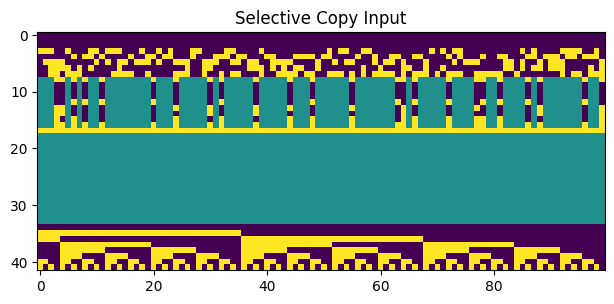

In [213]:
m = model.embedding(x) + model.pos_emb

plt.title("Selective Copy Input")
plt.tight_layout()

plt.imshow(m.detach().numpy()[0].T)

plt.savefig("fig/selective_copy_input.pdf")

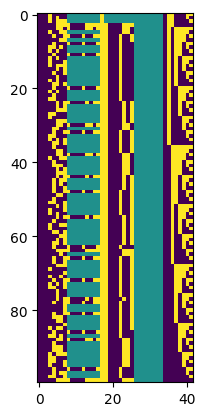

In [214]:
m = m + model.layers[0].layer(m)
plt.imshow(m.detach().numpy()[0])

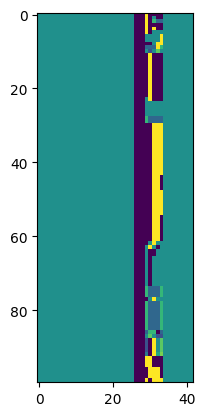

In [215]:
out, scores = model.layers[1].layer(m)
# plt.imshow((m+out).detach().numpy()[0])
plt.imshow((out).detach().numpy()[0])

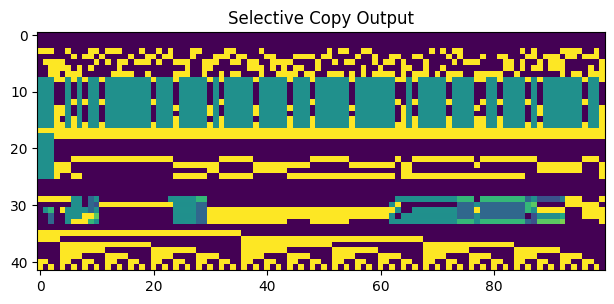

In [216]:
plt.title("Selective Copy Output")
plt.tight_layout()

plt.imshow((m+out).detach().numpy()[0].T)

plt.savefig("fig/selective_copy_output.pdf")

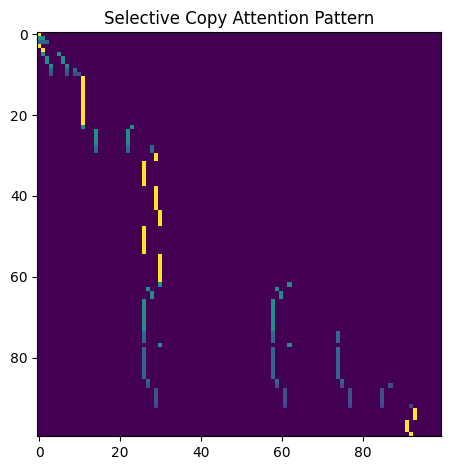

In [217]:
plt.title("Selective Copy Attention Pattern")
plt.tight_layout()

plt.imshow(scores.detach().numpy()[0,0])

plt.savefig("fig/selective_copy_atterntion_pattern.pdf")

In [218]:
qkv = model.layers[1].layer.qkv(m)
q, k, v = qkv.chunk(3, dim=-1)

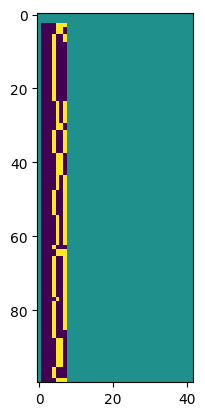

In [219]:
plt.imshow(q.detach().numpy()[0])

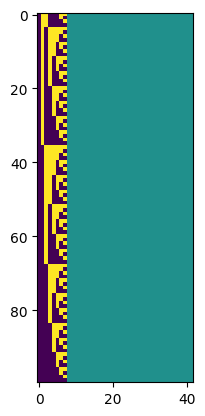

In [220]:
plt.imshow(k.detach().numpy()[0])

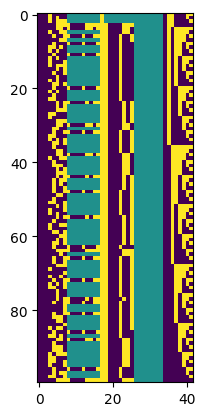

In [221]:
plt.imshow(v.detach().numpy()[0])

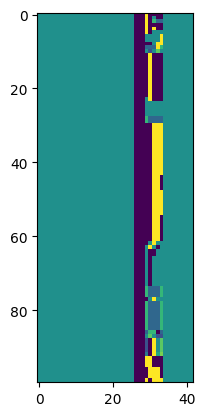

In [222]:
plt.imshow(out.detach().numpy()[0])

In [223]:
y

tensor([[33, 33, 33, 33, 33, 33, 33, 33, 15, 19, 22, 28, 27, 18, 30,  2, 29, 25,
         19, 29, 19, 16, 22,  4, 12, 29, 19,  7, 23, 26, 26,  4, 23, 26,  4,  6,
         23, 15, 30, 23, 20, 12,  7,  5, 18,  7, 13,  4, 18,  7, 13,  4,  6, 26,
         10,  7, 24,  4, 16, 19, 26,  7, 18, 26, 18, 15, 18, 15, 12,  2,  4, 12,
         29, 28,  1, 30,  8, 30, 15,  0, 17, 30, 20, 24,  3,  3, 30,  0, 13,  5,
          0, 21, 29, 25, 27,  7, 27,  7, 13, 22]])

In [224]:
(m+out)[0,-1, 3*l+2:4*l+2]

tensor([-1.0000, -1.0000, -1.0000,  1.0000, -1.0000,  1.0000,  1.0000,  1.0000],
       grad_fn=<SliceBackward0>)

In [225]:
y

tensor([[33, 33, 33, 33, 33, 33, 33, 33, 15, 19, 22, 28, 27, 18, 30,  2, 29, 25,
         19, 29, 19, 16, 22,  4, 12, 29, 19,  7, 23, 26, 26,  4, 23, 26,  4,  6,
         23, 15, 30, 23, 20, 12,  7,  5, 18,  7, 13,  4, 18,  7, 13,  4,  6, 26,
         10,  7, 24,  4, 16, 19, 26,  7, 18, 26, 18, 15, 18, 15, 12,  2,  4, 12,
         29, 28,  1, 30,  8, 30, 15,  0, 17, 30, 20, 24,  3,  3, 30,  0, 13,  5,
          0, 21, 29, 25, 27,  7, 27,  7, 13, 22]])